Progress: [####################] 100% Done...


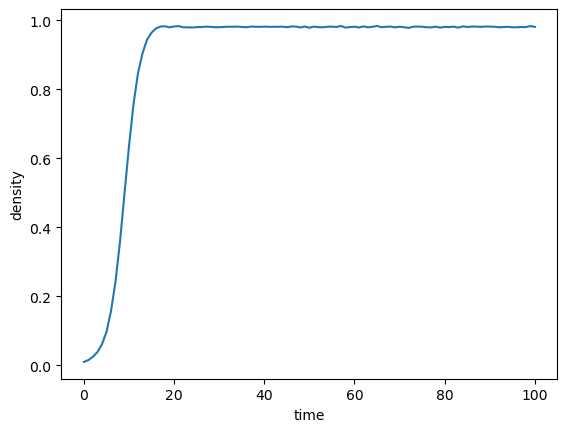

In [49]:
%matplotlib inline  
from lgca import get_lgca
import numpy.random as npr
import numpy as np
from bisect import bisect_left
from random import random
import matplotlib.pyplot as plt

def random_walk(lgca):
    """
    Shuffle config in the last axis, modeling a random walk.
    :return:
    """
    # disarrange(lgca.nodes, axis=-1)
    relevant = (lgca.cell_density[lgca.nonborder] > 0) & \
               (lgca.cell_density[lgca.nonborder] < lgca.K)
    coords = [a[relevant] for a in lgca.nonborder]
    for coord in zip(*coords):
        npr.shuffle(lgca.nodes[coord])

        
def birthae(lgca):
    """
    birth with allee growth
    :return:
    """ 
    birth = npr.random(lgca.nodes.shape) < lgca.r_b * lgca.cell_density[..., None]*(lgca.cell_density[..., None] + lgca.allee) / lgca.K
    np.add(lgca.nodes, (1 - lgca.nodes) * birth, out=lgca.nodes, casting='unsafe')
    random_walk(lgca)


def birthdeathae(lgca):
    """
    birth death with allee growth
    :return:
    """ 
    birth = npr.random(lgca.nodes.shape) < lgca.r_b * lgca.cell_density[..., None]*(lgca.cell_density[..., None] + lgca.allee) / lgca.K
    death = npr.random(lgca.nodes.shape) < lgca.r_d
    ds = (1 - lgca.nodes) * birth - lgca.nodes * death
    np.add(lgca.nodes, ds, out=lgca.nodes, casting='unsafe')
    random_walk(lgca)
    
#nodes = np.zeros((50, 50, 5))
#nodes[0, :, :] = 1
lgca = get_lgca(interaction='birthdeath' ,geometry='square', restchannels=1, density=0.01,
                r_b = 0.5, r_d = 0.02, bc='periodic')
lgca.interaction = birthdeathae
lgca.allee=0.5
lgca.timeevo(100,recordN=True)
plt.xlabel('time')
plt.ylabel('density')
plt.plot(lgca.n_t/(lgca.lx*lgca.ly*lgca.K))